In [1]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


Epsilon Greedy MBA

In [2]:
def epsilon_greedy(n_arms, true_means, n_steps, epsilon):

  Q = np.zeros(n_arms)
  N = np.zeros(n_arms)

  total_reward = 0

  rewards = []
  actions = []

  for step in range(n_steps):

    # Exploration
    if np.random.rand() < epsilon:
      action = np.random.randint(n_arms)   # Random arm

    # Exploitation
    else:
      best_actions = np.flatnonzero(Q == Q.max())
      action = np.random.choice(best_actions)  # Random among the best

    reward = np.random.normal(true_means[action], 1)

    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]

    total_reward += reward

    rewards.append(total_reward)
    actions.append(action)

  return total_reward, rewards, actions, Q, N

In [3]:
n_arms = 4

true_means = np.array([0.2, 0.9, 0.6, 0.4])

total_reward, rewards, actions, Q, N = epsilon_greedy(
  n_arms,
  true_means,
  1000,
  0.1
)

print("totalRewards: {total_reward}\n \
  Rewards: {rewards}\n\
  Actions: {actions}\n\
  Q: {Q}\n\
  N: {N}"\
  .format(
        total_reward=total_reward,
        rewards=rewards,
        actions=actions,
        Q=Q,
        N=N
    )
)

totalRewards: 570.5188880187568
   Rewards: [0.3911235013480568, 1.3788229685155897, 1.0948038144705063, 3.5148872136816323, 4.198425403889047, 3.209937342515519, 3.2548479119174973, 3.3524142775218886, 4.201593479330465, 3.4293342550002546, 2.6709388631516977, 0.9449346376258956, -0.13821307184309273, 1.3222025214980524, 0.6934974410918527, 2.7353074994029867, 2.5696895484306044, 2.650140394141507, 3.652068286504671, 5.139449531682395, 5.074463875029215, 5.5358224741818205, 6.071232127304204, 5.199543539263518, 6.691254749847715, 7.546240294355417, 7.162241594971203, 8.540355369156371, 9.675170908700583, 9.112796848958597, 12.015206434944238, 12.999109720518433, 14.253289235577302, 16.15748429665084, 14.0302695801414, 14.071351491562254, 13.876217543733285, 16.43264873831, 16.668949138527218, 17.17998179526521, 19.881120004947444, 20.83785363630419, 19.50135803370374, 20.783844224732384, 20.791743070649165, 22.764232297413283, 23.53361459400934, 22.639974011777003, 24.14462959648917, 

In [4]:
epsilons = [0.0, 0.01, 0.1, 0.3]

results = {}

for eps in epsilons:

  total_reward, rewards, actions, Q, N = epsilon_greedy(
    n_arms=n_arms,
    true_means=true_means,
    n_steps=1000,
    epsilon=eps
  )

  results[eps] = {
    "total_reward": total_reward,
    "rewards": rewards,
    "Q": Q,
    "N": N
  }

  print("=" * 50)
  print(f"Epsilon: {eps}")
  print(f"Total Reward: {total_reward:.2f}")
  print(f"Estimated Rewards (Q): {Q}")
  print(f"Number of selections (N): {N}")

Epsilon: 0.0
Total Reward: 611.23
Estimated Rewards (Q): [0.         0.         0.61122506 0.        ]
Number of selections (N): [   0.    0. 1000.    0.]
Epsilon: 0.01
Total Reward: 894.96
Estimated Rewards (Q): [0.25818034 0.90056662 0.40441302 0.38481259]
Number of selections (N): [  4. 990.   3.   3.]
Epsilon: 0.1
Total Reward: 804.83
Estimated Rewards (Q): [0.40295383 0.84072992 0.65182745 0.36619941]
Number of selections (N): [ 27. 906.  27.  40.]
Epsilon: 0.3
Total Reward: 758.32
Estimated Rewards (Q): [0.19145315 0.89662522 0.56881356 0.16237785]
Number of selections (N): [ 71. 759.  90.  80.]


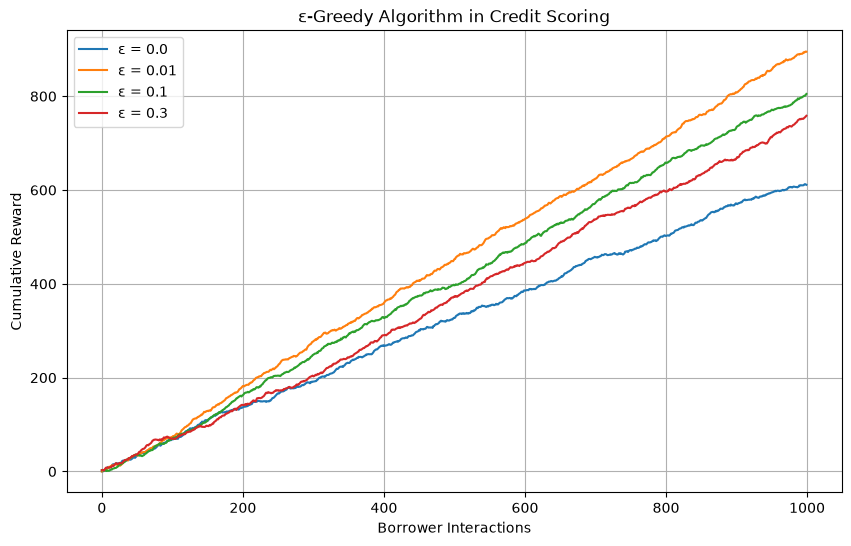

In [5]:
plt.figure(figsize=(10,6))

for eps in epsilons:
  plt.plot(results[eps]["rewards"], label=f"ε = {eps}")

plt.title("ε-Greedy Algorithm in Credit Scoring")
plt.xlabel("Borrower Interactions")
plt.ylabel("Cumulative Reward")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
print("Summary")
print("-" * 60)
print(f"{'Epsilon':<10}{'Total Reward':<18}{'Most Selected Arm'}")

for eps in epsilons:
  total = results[eps]["total_reward"]
  best_arm = np.argmax(results[eps]["N"])

  print(f"{eps:<10}{total:<18.2f}{best_arm}")

Summary
------------------------------------------------------------
Epsilon   Total Reward      Most Selected Arm
0.0       611.23            2
0.01      894.96            1
0.1       804.83            1
0.3       758.32            1


In [7]:
for eps in epsilons:
  print(f"\nε = {eps}")
  print("Arm selections:", results[eps]["N"])


ε = 0.0
Arm selections: [   0.    0. 1000.    0.]

ε = 0.01
Arm selections: [  4. 990.   3.   3.]

ε = 0.1
Arm selections: [ 27. 906.  27.  40.]

ε = 0.3
Arm selections: [ 71. 759.  90.  80.]
